<a href="https://colab.research.google.com/github/shreyoshi2304/Neurobiology-I/blob/main/Hodgkin_Huxley_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. MODEL PARAMETERS
# =========================
params = {
    "C_m": 1.0,
    "g_Na": 120.0,
    "g_K": 36.0,
    "g_L": 0.3,
    "E_Na": 50.0,
    "E_K": -77.0,
    "E_L": -54.387
}

# =========================
# 2. GATING FUNCTIONS (stable versions)
# =========================
def alpha_m(V):
    return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10) + 1e-9)

def beta_m(V):
    return 4.0 * np.exp(-(V + 65) / 18)

def alpha_h(V):
    return 0.07 * np.exp(-(V + 65) / 20)

def beta_h(V):
    return 1 / (1 + np.exp(-(V + 35) / 10))

def alpha_n(V):
    return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10) + 1e-9)

def beta_n(V):
    return 0.125 * np.exp(-(V + 65) / 80)

# =========================
# 3. CURRENT PROTOCOLS
# =========================
def step_current(t, t_on=10, t_off=80, amplitude=10):
    return amplitude * ((t > t_on) & (t < t_off))

def constant_current(t, amplitude=10):
    return amplitude * np.ones_like(t)

# =========================
# 4. SIMULATION FUNCTION
# =========================
def simulate_HH(T=100, dt=0.01, I_func=step_current, I_amp=10):

    t = np.arange(0, T, dt)
    N = len(t)

    V = np.zeros(N)
    m = np.zeros(N)
    h = np.zeros(N)
    n = np.zeros(N)

    # Initial conditions
    V[0] = -65

    m[0] = alpha_m(V[0]) / (alpha_m(V[0]) + beta_m(V[0]))
    h[0] = alpha_h(V[0]) / (alpha_h(V[0]) + beta_h(V[0]))
    n[0] = alpha_n(V[0]) / (alpha_n(V[0]) + beta_n(V[0]))

    for i in range(N - 1):
        I = I_func(np.array([t[i]]), amplitude=I_amp)[0]

        gNa = params["g_Na"] * (m[i]**3) * h[i]
        gK = params["g_K"] * (n[i]**4)
        gL = params["g_L"]

        dVdt = (
            I
            - gNa * (V[i] - params["E_Na"])
            - gK * (V[i] - params["E_K"])
            - gL * (V[i] - params["E_L"])
        ) / params["C_m"]

        V[i+1] = V[i] + dt * dVdt

        m[i+1] = m[i] + dt * (alpha_m(V[i])*(1 - m[i]) - beta_m(V[i])*m[i])
        h[i+1] = h[i] + dt * (alpha_h(V[i])*(1 - h[i]) - beta_h(V[i])*h[i])
        n[i+1] = n[i] + dt * (alpha_n(V[i])*(1 - n[i]) - beta_n(V[i])*n[i])

    return t, V, m, h, n

In [2]:
def compute_spike_times(V, t, threshold=0):
    spikes = []
    for i in range(1, len(V)):
        if V[i-1] < threshold and V[i] >= threshold:
            spikes.append(t[i])
    return np.array(spikes)

def firing_rate(spike_times, T):
    if len(spike_times) < 2:
        return 0
    return len(spike_times) / (T / 1000)  # Hz

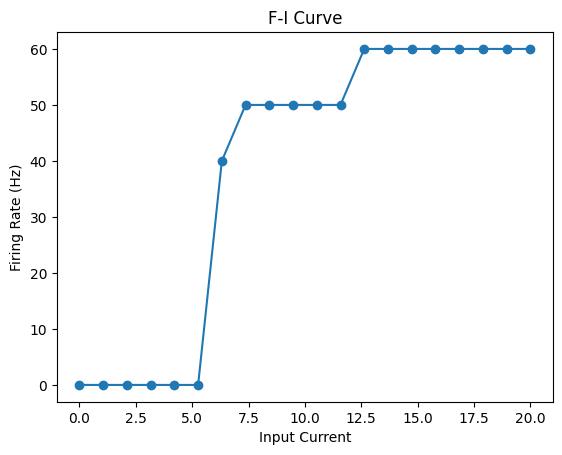

In [3]:
def FI_curve(currents):
    rates = []

    for I in currents:
        t, V, _, _, _ = simulate_HH(I_amp=I)
        spikes = compute_spike_times(V, t)
        rate = firing_rate(spikes, t[-1])
        rates.append(rate)

    return rates

currents = np.linspace(0, 20, 20)
rates = FI_curve(currents)

plt.figure()
plt.plot(currents, rates, 'o-')
plt.xlabel("Input Current")
plt.ylabel("Firing Rate (Hz)")
plt.title("F-I Curve")
plt.show()

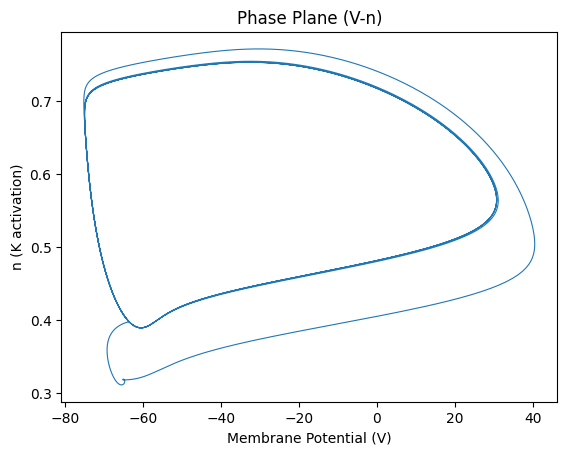

In [4]:
t, V, m, h, n = simulate_HH()

plt.figure()
plt.plot(V, n, linewidth=0.8)
plt.xlabel("Membrane Potential (V)")
plt.ylabel("n (K activation)")
plt.title("Phase Plane (V-n)")
plt.show()

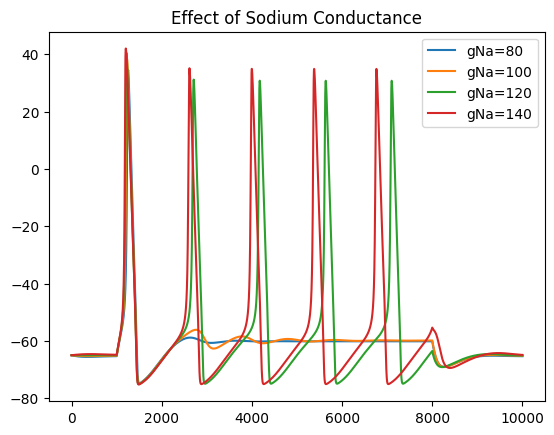

In [5]:
def vary_gNa(values):
    results = []

    for g in values:
        params["g_Na"] = g
        t, V, _, _, _ = simulate_HH(I_amp=10)
        results.append(V)

    return results

gNa_values = [80, 100, 120, 140]
results = vary_gNa(gNa_values)

plt.figure()
for i, V in enumerate(results):
    plt.plot(V, label=f"gNa={gNa_values[i]}")
plt.legend()
plt.title("Effect of Sodium Conductance")
plt.show()

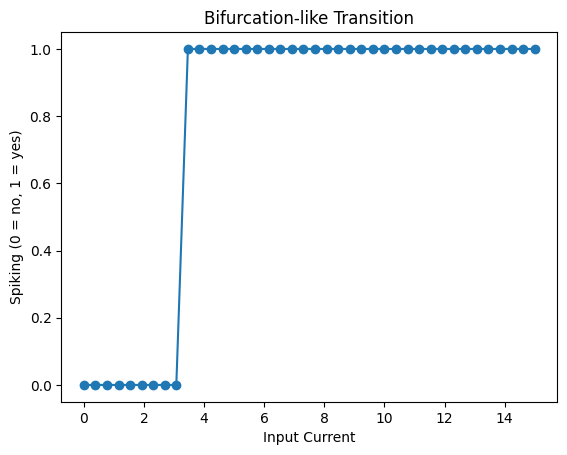

Critical current ~ 3.4615384615384617


In [6]:
def detect_spiking(V, t, threshold=0):
    spikes = []
    for i in range(1, len(V)):
        if V[i-1] < threshold and V[i] >= threshold:
            spikes.append(t[i])
    return len(spikes) > 3  # sustained spiking


def bifurcation_scan(I_values):
    spiking = []

    for I in I_values:
        t, V, _, _, _ = simulate_HH(T=200, I_amp=I)
        is_spiking = detect_spiking(V, t)
        spiking.append(is_spiking)

    return spiking


I_values = np.linspace(0, 15, 40)
spiking = bifurcation_scan(I_values)

plt.figure()
plt.plot(I_values, spiking, 'o-')
plt.xlabel("Input Current")
plt.ylabel("Spiking (0 = no, 1 = yes)")
plt.title("Bifurcation-like Transition")
plt.show()


# Estimate critical current
for I, s in zip(I_values, spiking):
    if s:
        print("Critical current ~", I)
        break

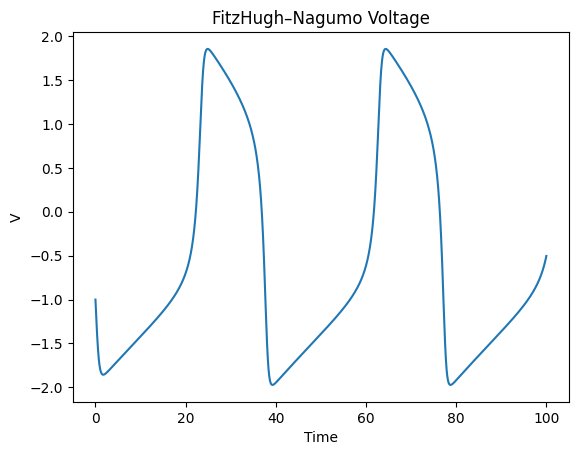

In [7]:
def simulate_FHN(T=100, dt=0.01, I=0.5):
    t = np.arange(0, T, dt)

    V = np.zeros(len(t))
    W = np.zeros(len(t))

    # initial conditions
    V[0] = -1
    W[0] = 1

    a = 0.7
    b = 0.8
    tau = 12.5

    for i in range(len(t)-1):
        dV = V[i] - (V[i]**3)/3 - W[i] + I
        dW = (V[i] + a - b*W[i]) / tau

        V[i+1] = V[i] + dt*dV
        W[i+1] = W[i] + dt*dW

    return t, V, W


# Run
t_fhn, V_fhn, W_fhn = simulate_FHN()

plt.figure()
plt.plot(t_fhn, V_fhn)
plt.title("FitzHugh–Nagumo Voltage")
plt.xlabel("Time")
plt.ylabel("V")
plt.show()

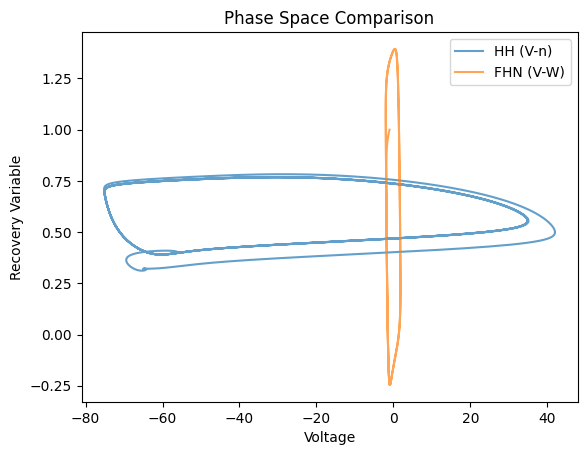

In [8]:
# HH phase (V vs n)
t, V, m, h, n = simulate_HH()

plt.figure()
plt.plot(V, n, label="HH (V-n)", alpha=0.7)
plt.plot(V_fhn, W_fhn, label="FHN (V-W)", alpha=0.7)
plt.xlabel("Voltage")
plt.ylabel("Recovery Variable")
plt.legend()
plt.title("Phase Space Comparison")
plt.show()

In [9]:
def simulate_HH_noise(T=100, dt=0.01, I_amp=10, noise_std=2.0):

    t = np.arange(0, T, dt)
    N = len(t)

    V = np.zeros(N)
    m = np.zeros(N)
    h = np.zeros(N)
    n = np.zeros(N)

    V[0] = -65

    m[0] = alpha_m(V[0]) / (alpha_m(V[0]) + beta_m(V[0]))
    h[0] = alpha_h(V[0]) / (alpha_h(V[0]) + beta_h(V[0]))
    n[0] = alpha_n(V[0]) / (alpha_n(V[0]) + beta_n(V[0]))

    for i in range(N - 1):
        noise = np.random.normal(0, noise_std)
        I = step_current(np.array([t[i]]), amplitude=I_amp)[0] + noise

        gNa = params["g_Na"] * (m[i]**3) * h[i]
        gK = params["g_K"] * (n[i]**4)

        dVdt = (
            I
            - gNa * (V[i] - params["E_Na"])
            - gK * (V[i] - params["E_K"])
            - params["g_L"] * (V[i] - params["E_L"])
        ) / params["C_m"]

        V[i+1] = V[i] + dt * dVdt

        m[i+1] = m[i] + dt*(alpha_m(V[i])*(1-m[i]) - beta_m(V[i])*m[i])
        h[i+1] = h[i] + dt*(alpha_h(V[i])*(1-h[i]) - beta_h(V[i])*h[i])
        n[i+1] = n[i] + dt*(alpha_n(V[i])*(1-n[i]) - beta_n(V[i])*n[i])

    return t, V

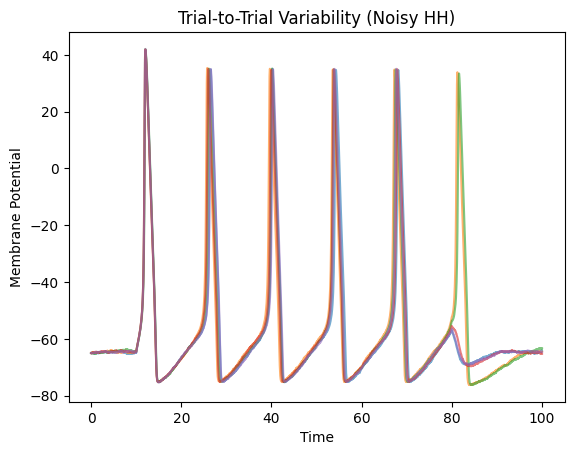

In [10]:
plt.figure()

for _ in range(5):
    t, V = simulate_HH_noise(noise_std=3.0)
    plt.plot(t, V, alpha=0.6)

plt.xlabel("Time")
plt.ylabel("Membrane Potential")
plt.title("Trial-to-Trial Variability (Noisy HH)")
plt.show()